In [1]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

print("PyTorch version:", torch.__version__)

PyTorch version: 2.3.1


In [2]:
# RF environment settings
FREQ_MIN_MHZ = 0
FREQ_MAX_MHZ = 18_000
FREQ_BIN_MHZ = 500
TIME_BIN_S = 0.050

N_FREQ_BINS = int(
    (FREQ_MAX_MHZ - FREQ_MIN_MHZ) / FREQ_BIN_MHZ
)

# ML settings
HIDDEN_SIZE = 128
PROB_EPS = 1e-4

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# ============================================================
# RECURSIVE TRAINING CONFIGURATION
# ============================================================

TBPTT_LENGTH = 32

RECURSIVE_EPOCHS = 20

RECURSIVE_LEARNING_RATE = 1e-3

print("TBPTT length:", TBPTT_LENGTH)
print("Recursive epochs:", RECURSIVE_EPOCHS)
print("Learning rate:", RECURSIVE_LEARNING_RATE)

TBPTT length: 32
Recursive epochs: 20
Learning rate: 0.001


In [4]:
TRAIN_RFENV_DIR = Path("./train_RFEnvs")
TRAIN_FINAL_DIR = Path("./train_final")

TRAIN_FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

P_BASELINE_PATH = (
    TRAIN_FINAL_DIR / "P_baseline.npy"
)

print("RF environments:", TRAIN_RFENV_DIR.resolve())
print("Final directory:", TRAIN_FINAL_DIR.resolve())

RF environments: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_RFEnvs
Final directory: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final


In [5]:
rf_files = sorted(
    p for p in TRAIN_RFENV_DIR.glob("*.npy")
    if p.name != "environment_config.npy"
)

if len(rf_files) == 0:
    raise FileNotFoundError(
        f"No RF environment files found in {TRAIN_RFENV_DIR}"
    )

print(f"Found {len(rf_files)} RF environments.")

# Quick sanity check
for path in rf_files[:5]:
    env = np.load(path)

    print(
        f"{path.name:25s} "
        f"shape={env.shape} "
        f"occupancy={env.mean():.2%}"
    )

Found 5 RF environments.
config_0.npy              shape=(598, 36) occupancy=34.96%
config_1.npy              shape=(597, 36) occupancy=25.25%
config_10.npy             shape=(671, 36) occupancy=20.28%
config_100.npy            shape=(600, 36) occupancy=26.19%
config_1000.npy           shape=(577, 36) occupancy=7.38%


In [6]:
P_baseline = np.load(
    P_BASELINE_PATH
).astype(np.float32)

if P_baseline.shape != (N_FREQ_BINS,):
    raise ValueError(
        f"Expected baseline shape "
        f"({N_FREQ_BINS},), got {P_baseline.shape}"
    )

# Smooth exact 0/1 values.
P_baseline = np.clip(
    P_baseline,
    PROB_EPS,
    1.0 - PROB_EPS
)

print("P_baseline shape:", P_baseline.shape)
print("Min:", P_baseline.min())
print("Max:", P_baseline.max())

P_baseline shape: (36,)
Min: 1e-04
Max: 0.91393507


In [7]:
# ============================================================
# RECURSIVE BELIEF UPDATE MODEL
# ============================================================
# We use One-Hot Encoding for the observations of any of the 36 bands

class BeliefUpdater(nn.Module):

    def __init__(
        self,
        n_bands=36,
        hidden_size=128
    ):
        super().__init__()

        self.n_bands = n_bands

        input_size = (
            n_bands      # previous probabilities
            + n_bands    # chosen action (one-hot)
            + 1          # hit / miss
        )

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, n_bands)
        )

    def forward(
        self,
        probabilities,
        actions,
        observations
    ):

        # actions:
        # shape = (batch,)
        #
        # Convert each chosen band into a one-hot vector.
        action_one_hot = torch.zeros(
            actions.shape[0],
            self.n_bands,
            device=actions.device
        )

        action_one_hot.scatter_(
            1,
            actions.unsqueeze(1),
            1.0
        )

        # observations:
        # shape = (batch,)
        # Convert to column vector.
        observations = observations.float().unsqueeze(1)

        x = torch.cat(
            [
                probabilities,
                action_one_hot,
                observations
            ],
            dim=1
        )

        logits = self.network(x)

        return logits

In [8]:
# ============================================================
# FRESH RANDOMLY INITIALIZED MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

recursive_model = BeliefUpdater(
    n_bands=N_FREQ_BINS,
    hidden_size=HIDDEN_SIZE
).to(device)

recursive_optimizer = torch.optim.Adam(
    recursive_model.parameters(),
    lr=RECURSIVE_LEARNING_RATE
)

recursive_criterion = nn.BCEWithLogitsLoss()

print("Fresh recursive model created.")
print("Weights are randomly initialized.")

Fresh recursive model created.
Weights are randomly initialized.


In [9]:
# ============================================================
# ONE RECURSIVE TRAINING EPISODE
# ============================================================

def train_recursive_episode(
    model,
    optimizer,
    criterion,
    rf_env,
    p_baseline,
    tbptt_length=32,
    device="cpu"
):
    """
    Train the model on one RF environment using
    recursive belief updates.

    The model starts from P_baseline.

    At each timestep:

        choose random band
        observe hit/miss
        predict next probability state
        compare against actual next RF state

    Backpropagation is performed every tbptt_length
    timesteps.
    """

    model.train()

    n_steps, n_bands = rf_env.shape

    # --------------------------------------------------------
    # Initial belief
    # --------------------------------------------------------

    current_probabilities = torch.tensor(
        p_baseline,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    total_loss = 0.0
    n_chunks = 0

    # --------------------------------------------------------
    # Walk through RF environment
    # --------------------------------------------------------

    for chunk_start in range(
        0,
        n_steps - 1,
        tbptt_length
    ):

        chunk_end = min(
            chunk_start + tbptt_length,
            n_steps - 1
        )

        optimizer.zero_grad()

        chunk_loss = 0.0

        # ----------------------------------------------------
        # Recursive rollout within this chunk
        # ----------------------------------------------------

        for t in range(
            chunk_start,
            chunk_end
        ):

            # Random scanner chooses ONE band.
            action = np.random.randint(
                0,
                n_bands
            )

            # Actual observation from RF environment.
            observation = rf_env[t, action]

            # Convert to tensors.
            action_tensor = torch.tensor(
                [action],
                dtype=torch.long,
                device=device
            )

            observation_tensor = torch.tensor(
                [observation],
                dtype=torch.float32,
                device=device
            )

            # Ground truth at NEXT timestep.
            target = torch.tensor(
                rf_env[t + 1],
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            # ------------------------------------------------
            # MODEL UPDATE
            # ------------------------------------------------

            logits = model(
                current_probabilities,
                action_tensor,
                observation_tensor
            )

            # Probability prediction.
            predicted_probabilities = torch.sigmoid(
                logits
            )

            # ------------------------------------------------
            # LOSS
            # ------------------------------------------------

            step_loss = criterion(
                logits,
                target
            )

            chunk_loss = chunk_loss + step_loss

            # ------------------------------------------------
            # RECURSIVE STATE
            # ------------------------------------------------

            current_probabilities = (
                predicted_probabilities
            )

        # ----------------------------------------------------
        # Average loss across this chunk
        # ----------------------------------------------------

        chunk_loss = (
            chunk_loss /
            (chunk_end - chunk_start)
        )

        # ----------------------------------------------------
        # Backprop through this chunk
        # ----------------------------------------------------

        chunk_loss.backward()

        # Prevent exploding gradients.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += chunk_loss.item()
        n_chunks += 1

        # ----------------------------------------------------
        # IMPORTANT:
        # Keep the belief, but stop its computation graph.
        # ----------------------------------------------------

        current_probabilities = (
            current_probabilities.detach()
        )

    return total_loss / n_chunks    

In [10]:
# ============================================================
# FULL RECURSIVE TRAINING
# ============================================================

recursive_loss_history = []

for epoch in range(RECURSIVE_EPOCHS):

    epoch_losses = []

    # Shuffle environment order every epoch.
    shuffled_files = rf_files.copy()
    random.shuffle(shuffled_files)

    for path in shuffled_files:

        rf_env = np.load(path)

        loss = train_recursive_episode(
            model=recursive_model,
            optimizer=recursive_optimizer,
            criterion=recursive_criterion,
            rf_env=rf_env,
            p_baseline=P_baseline,
            tbptt_length=TBPTT_LENGTH,
            device=device
        )

        epoch_losses.append(loss)

    epoch_loss = np.mean(epoch_losses)

    recursive_loss_history.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch + 1:2d}/{RECURSIVE_EPOCHS} "
        f"| Recursive loss: {epoch_loss:.6f}"
    )

Epoch  1/20 | Recursive loss: 0.415282
Epoch  2/20 | Recursive loss: 0.319546
Epoch  3/20 | Recursive loss: 0.303358
Epoch  4/20 | Recursive loss: 0.305893
Epoch  5/20 | Recursive loss: 0.297351
Epoch  6/20 | Recursive loss: 0.302092
Epoch  7/20 | Recursive loss: 0.298911
Epoch  8/20 | Recursive loss: 0.302420
Epoch  9/20 | Recursive loss: 0.296826
Epoch 10/20 | Recursive loss: 0.297427
Epoch 11/20 | Recursive loss: 0.295714
Epoch 12/20 | Recursive loss: 0.296645
Epoch 13/20 | Recursive loss: 0.292016
Epoch 14/20 | Recursive loss: 0.295443
Epoch 15/20 | Recursive loss: 0.291068
Epoch 16/20 | Recursive loss: 0.302391
Epoch 17/20 | Recursive loss: 0.290629
Epoch 18/20 | Recursive loss: 0.289979
Epoch 19/20 | Recursive loss: 0.295011
Epoch 20/20 | Recursive loss: 0.295036


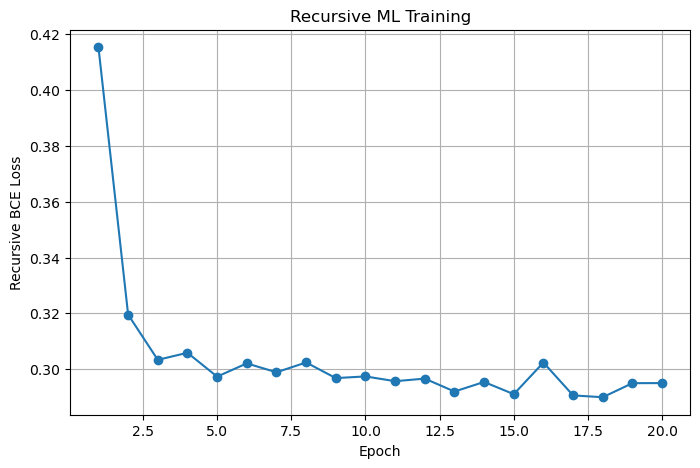

In [11]:
# ============================================================
# RECURSIVE TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, RECURSIVE_EPOCHS + 1),
    recursive_loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Recursive BCE Loss")
plt.title("Recursive ML Training")

plt.grid(True)
plt.show()

In [12]:
# ============================================================
# FINAL MODEL CONFIGURATION
# ============================================================

MODEL_CONFIG = {
    # RF environment
    "freq_min_mhz": FREQ_MIN_MHZ,
    "freq_max_mhz": FREQ_MAX_MHZ,
    "freq_bin_mhz": FREQ_BIN_MHZ,
    "time_bin_s": TIME_BIN_S,
    "n_freq_bins": N_FREQ_BINS,

    # Model architecture
    "hidden_size": HIDDEN_SIZE,

    # Training
    "learning_rate": RECURSIVE_LEARNING_RATE,
    "epochs": RECURSIVE_EPOCHS,
    "tbptt_length": TBPTT_LENGTH,

    # Initialization / prior
    "initial_belief": "P_baseline",

    # Training scan policy
    "training_scan_policy": "uniform_random",

    # Loss
    "loss": "BCEWithLogitsLoss",
}

MODEL_CONFIG

{'freq_min_mhz': 0,
 'freq_max_mhz': 18000,
 'freq_bin_mhz': 500,
 'time_bin_s': 0.05,
 'n_freq_bins': 36,
 'hidden_size': 128,
 'learning_rate': 0.001,
 'epochs': 20,
 'tbptt_length': 32,
 'initial_belief': 'P_baseline',
 'training_scan_policy': 'uniform_random',
 'loss': 'BCEWithLogitsLoss'}

In [13]:
# ============================================================
# SAVE FINAL TRAINED MODEL
# ============================================================

MODEL_SAVE_PATH = (
    TRAIN_FINAL_DIR / "recursive_belief_updater.pt"
)

checkpoint = {
    # Neural network weights
    "model_state_dict": recursive_model.state_dict(),

    # Architecture / training configuration
    "model_config": MODEL_CONFIG,

    # Baseline prior used to initialize P_0
    "P_baseline": P_baseline,

    # Useful metadata
    "model_name": "Recursive Belief Updater",
    "n_bands": N_FREQ_BINS,
}

torch.save(
    checkpoint,
    MODEL_SAVE_PATH
)

print("Model saved to:")
print(MODEL_SAVE_PATH.resolve())

Model saved to:
C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\recursive_belief_updater.pt


In [14]:
# ============================================================
# SAVE MODEL CONFIGURATION
# ============================================================

CONFIG_SAVE_PATH = (
    TRAIN_FINAL_DIR / "recursive_belief_updater_config.json"
)

with open(
    CONFIG_SAVE_PATH,
    "w"
) as f:

    json.dump(
        MODEL_CONFIG,
        f,
        indent=4
    )

print("Configuration saved to:")
print(CONFIG_SAVE_PATH.resolve())

Configuration saved to:
C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\recursive_belief_updater_config.json


In [15]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=device,
    weights_only=False
)

loaded_config = checkpoint["model_config"]

loaded_model = BeliefUpdater(
    n_bands=loaded_config["n_freq_bins"],
    hidden_size=loaded_config["hidden_size"]
).to(device)

loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

loaded_model.eval()

loaded_baseline = checkpoint["P_baseline"]

print("Saved model loaded successfully.")

print("Bands:", loaded_config["n_freq_bins"])
print("Hidden size:", loaded_config["hidden_size"])
print("TBPTT length:", loaded_config["tbptt_length"])
print("Time bin:", loaded_config["time_bin_s"], "s")

Saved model loaded successfully.
Bands: 36
Hidden size: 128
TBPTT length: 32
Time bin: 0.05 s


In [16]:
# ============================================================
# VERIFY LOADED MODEL OUTPUT
# ============================================================

test_probability = torch.tensor(
    P_baseline,
    dtype=torch.float32,
    device=device
).unsqueeze(0)

test_action = torch.tensor(
    [0],
    dtype=torch.long,
    device=device
)

test_observation = torch.tensor(
    [0.0],
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    original_output = torch.sigmoid(
        recursive_model(
            test_probability,
            test_action,
            test_observation
        )
    )

    loaded_output = torch.sigmoid(
        loaded_model(
            test_probability,
            test_action,
            test_observation
        )
    )

max_difference = torch.max(
    torch.abs(
        original_output - loaded_output
    )
).item()

print(
    f"Maximum prediction difference: "
    f"{max_difference:.12f}"
)

if max_difference < 1e-7:
    print("✓ Saved model matches original model.")
else:
    print("⚠ Saved model differs from original.")

Maximum prediction difference: 0.000000000000
✓ Saved model matches original model.


In [17]:
# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

TRAINING_HISTORY_PATH = (
    TRAIN_FINAL_DIR / "recursive_training_history.json"
)

training_history = {
    "recursive_loss": recursive_loss_history
}

with open(
    TRAINING_HISTORY_PATH,
    "w"
) as f:

    json.dump(
        training_history,
        f,
        indent=4
    )

print("Training history saved to:")
print(TRAINING_HISTORY_PATH.resolve())

Training history saved to:
C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\recursive_training_history.json


In [20]:
# ============================================================
# RECURSIVE BELIEF DIAGNOSTICS - VALIDATION SET
# ============================================================

import numpy as np
import torch
import random
from pathlib import Path


recursive_model.eval()


# ============================================================
# VALIDATION FILES
# ============================================================

VAL_DIR = Path("val_RFEnvs")

val_files = sorted(
    VAL_DIR.glob("*.npy"),
    key=lambda p: p.name
)

print(f"Validation environments found: {len(val_files)}")
print([p.name for p in val_files])


# ============================================================
# SETTINGS
# ============================================================

N_TEST_ENVS = len(val_files)

CHANGE_THRESHOLD = 0.10


# ============================================================
# STORAGE
# ============================================================

baseline_bces = []
recursive_bces = []

belief_change_over_time = []

real_final_beliefs = []
zero_final_beliefs = []
one_final_beliefs = []

action_sensitivity = []
observation_sensitivity = []


# ============================================================
# TEST EACH VALIDATION ENVIRONMENT
# ============================================================

for env_idx, path in enumerate(val_files[:N_TEST_ENVS]):

    env = np.load(path).astype(np.float32)

    print(
        f"\nTesting {path.name} "
        f"({env.shape[0]} time steps × {env.shape[1]} bands)"
    )

    # --------------------------------------------------------
    # Initial belief
    # --------------------------------------------------------

    initial_belief = torch.tensor(
        P_baseline,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    belief = initial_belief.clone()

    # Same reproducible random scan
    rng = random.Random(123)

    env_bce_baseline = []
    env_bce_recursive = []
    env_belief_changes = []

    # --------------------------------------------------------
    # Recursive rollout
    # --------------------------------------------------------

    with torch.no_grad():

        for t in range(len(env) - 1):

            # Random scan
            action = rng.randrange(N_FREQ_BINS)

            # Scanner observes ONLY chosen band
            observation = float(env[t, action])

            action_tensor = torch.tensor(
                [action],
                dtype=torch.long,
                device=device
            )

            observation_tensor = torch.tensor(
                [observation],
                dtype=torch.float32,
                device=device
            )

            # ------------------------------------------------
            # Target = actual next environment state
            # ------------------------------------------------

            target = torch.tensor(
                env[t + 1],
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            # ------------------------------------------------
            # Baseline prediction
            # ------------------------------------------------

            baseline_tensor = torch.tensor(
                P_baseline,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            baseline_bce = torch.nn.functional.binary_cross_entropy(
                baseline_tensor,
                target
            )

            env_bce_baseline.append(
                baseline_bce.item()
            )

            # ------------------------------------------------
            # Recursive model prediction
            # ------------------------------------------------

            logits = recursive_model(
                belief,
                action_tensor,
                observation_tensor
            )

            next_belief = torch.sigmoid(logits)

            recursive_bce = torch.nn.functional.binary_cross_entropy(
                next_belief,
                target
            )

            env_bce_recursive.append(
                recursive_bce.item()
            )

            # ------------------------------------------------
            # Belief movement
            # ------------------------------------------------

            step_change = torch.abs(
                next_belief - belief
            ).mean().item()

            env_belief_changes.append(
                step_change
            )

            # Recursive update
            belief = next_belief

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    baseline_bces.extend(env_bce_baseline)
    recursive_bces.extend(env_bce_recursive)

    belief_change_over_time.append(
        env_belief_changes
    )

    real_final_beliefs.append(
        belief.squeeze(0).cpu().numpy()
    )


    # ========================================================
    # OBSERVATION SENSITIVITY
    # ========================================================

    test_belief = initial_belief.clone()

    test_action = 0

    action_tensor = torch.tensor(
        [test_action],
        dtype=torch.long,
        device=device
    )

    observation_zero = torch.tensor(
        [0.0],
        dtype=torch.float32,
        device=device
    )

    observation_one = torch.tensor(
        [1.0],
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():

        output_zero = torch.sigmoid(
            recursive_model(
                test_belief,
                action_tensor,
                observation_zero
            )
        )

        output_one = torch.sigmoid(
            recursive_model(
                test_belief,
                action_tensor,
                observation_one
            )
        )

    obs_difference = torch.abs(
        output_one - output_zero
    ).mean().item()

    observation_sensitivity.append(
        obs_difference
    )

    zero_final_beliefs.append(
        output_zero.squeeze(0).cpu().numpy()
    )

    one_final_beliefs.append(
        output_one.squeeze(0).cpu().numpy()
    )


    # ========================================================
    # ACTION SENSITIVITY
    # ========================================================

    action_outputs = []

    with torch.no_grad():

        for test_action in range(N_FREQ_BINS):

            action_tensor = torch.tensor(
                [test_action],
                dtype=torch.long,
                device=device
            )

            output = torch.sigmoid(
                recursive_model(
                    test_belief,
                    action_tensor,
                    observation_zero
                )
            )

            action_outputs.append(
                output.squeeze(0).cpu().numpy()
            )

    action_outputs = np.stack(action_outputs)

    action_mean = action_outputs.mean(axis=0)

    action_difference = np.abs(
        action_outputs - action_mean
    ).mean()

    action_sensitivity.append(
        action_difference
    )


# ============================================================
# SUMMARY 1: BASELINE vs RECURSIVE BCE
# ============================================================

mean_baseline_bce = np.mean(baseline_bces)
mean_recursive_bce = np.mean(recursive_bces)

improvement = (
    mean_baseline_bce - mean_recursive_bce
)

improvement_percent = (
    improvement / mean_baseline_bce * 100
)


print()
print("=" * 70)
print("1. VALIDATION: BASELINE vs RECURSIVE PREDICTION")
print("=" * 70)

print(
    f"Environments tested   : {N_TEST_ENVS}"
)

print(
    f"Baseline BCE          : {mean_baseline_bce:.6f}"
)

print(
    f"Recursive BCE         : {mean_recursive_bce:.6f}"
)

print(
    f"Improvement           : {improvement:+.6f}"
)

print(
    f"Improvement (%)       : {improvement_percent:+.2f}%"
)

if mean_recursive_bce < mean_baseline_bce:
    print("\n✓ Recursive model beats the baseline.")
else:
    print("\n✗ Recursive model does NOT beat the baseline.")


# ============================================================
# SUMMARY 2: BELIEF MOVEMENT
# ============================================================

print()
print("=" * 70)
print("2. VALIDATION: BELIEF MOVEMENT")
print("=" * 70)

all_changes = np.concatenate(
    belief_change_over_time
)

print(
    f"Mean step-to-step change   : "
    f"{np.mean(all_changes):.6f}"
)

print(
    f"Median step-to-step change : "
    f"{np.median(all_changes):.6f}"
)

print(
    f"Maximum step change        : "
    f"{np.max(all_changes):.6f}"
)


final_vs_baseline = []

for final_belief in real_final_beliefs:

    final_vs_baseline.append(
        np.abs(
            final_belief - P_baseline
        ).mean()
    )

print(
    f"\nMean final-vs-baseline    : "
    f"{np.mean(final_vs_baseline):.6f}"
)


# ============================================================
# SUMMARY 3: OBSERVATION SENSITIVITY
# ============================================================

print()
print("=" * 70)
print("3. VALIDATION: HIT / MISS SENSITIVITY")
print("=" * 70)

mean_obs_sensitivity = np.mean(
    observation_sensitivity
)

print(
    f"Mean |output(obs=1) - output(obs=0)| : "
    f"{mean_obs_sensitivity:.8f}"
)

if mean_obs_sensitivity > 0.001:
    print(
        "\n✓ Model responds measurably to the observation."
    )
else:
    print(
        "\n⚠ Model barely responds to the observation."
    )


# ============================================================
# SUMMARY 4: ACTION SENSITIVITY
# ============================================================

print()
print("=" * 70)
print("4. VALIDATION: ACTION SENSITIVITY")
print("=" * 70)

mean_action_sensitivity = np.mean(
    action_sensitivity
)

print(
    f"Mean action sensitivity : "
    f"{mean_action_sensitivity:.8f}"
)

if mean_action_sensitivity > 0.001:
    print(
        "\n✓ Model responds measurably to the selected band."
    )
else:
    print(
        "\n⚠ Model barely responds to the selected band."
    )


# ============================================================
# SUMMARY 5: LARGE FINAL BELIEF CHANGES
# ============================================================

changed_fractions = []

for final_belief in real_final_beliefs:

    difference = np.abs(
        final_belief - P_baseline
    )

    changed_fraction = np.mean(
        difference >= CHANGE_THRESHOLD
    )

    changed_fractions.append(
        changed_fraction
    )

print()
print("=" * 70)
print("5. VALIDATION: LARGE FINAL BELIEF CHANGES")
print("=" * 70)

print(
    f"Mean fraction of bands changing >= 0.10 : "
    f"{np.mean(changed_fractions):.2%}"
)


# ============================================================
# SUMMARY 6: REAL vs ZERO vs ONE OBSERVATIONS
# ============================================================

real_final_mean = np.mean(
    np.stack(real_final_beliefs),
    axis=0
)

zero_final_mean = np.mean(
    np.stack(zero_final_beliefs),
    axis=0
)

one_final_mean = np.mean(
    np.stack(one_final_beliefs),
    axis=0
)

real_vs_zero = np.abs(
    real_final_mean - zero_final_mean
).mean()

real_vs_one = np.abs(
    real_final_mean - one_final_mean
).mean()

zero_vs_one = np.abs(
    zero_final_mean - one_final_mean
).mean()


print()
print("=" * 70)
print("6. VALIDATION: REAL vs ZERO vs ONE")
print("=" * 70)

print(
    f"Real vs all-zero : {real_vs_zero:.8f}"
)

print(
    f"Real vs all-one  : {real_vs_one:.8f}"
)

print(
    f"Zero vs one      : {zero_vs_one:.8f}"
)


# ============================================================
# FINAL VERDICT
# ============================================================

print()
print("=" * 70)
print("VALIDATION DIAGNOSTIC VERDICT")
print("=" * 70)

if mean_recursive_bce < mean_baseline_bce:
    print("✓ Prediction quality: GOOD")
else:
    print("✗ Prediction quality: NEEDS WORK")

if mean_obs_sensitivity > 0.001:
    print("✓ Observation is being used")
else:
    print("⚠ Observation may be ignored")

if mean_action_sensitivity > 0.001:
    print("✓ Action is being used")
else:
    print("⚠ Action may be ignored")

if np.mean(all_changes) > 0.001:
    print("✓ Belief is changing during recursion")
else:
    print("⚠ Belief is barely changing")

print("=" * 70)

Validation environments found: 4
['config_0.npy', 'config_1.npy', 'config_10.npy', 'config_100.npy']

Testing config_0.npy (535 time steps × 36 bands)

Testing config_1.npy (850 time steps × 36 bands)

Testing config_10.npy (598 time steps × 36 bands)

Testing config_100.npy (593 time steps × 36 bands)

1. VALIDATION: BASELINE vs RECURSIVE PREDICTION
Environments tested   : 4
Baseline BCE          : 0.408060
Recursive BCE         : 0.380030
Improvement           : +0.028031
Improvement (%)       : +6.87%

✓ Recursive model beats the baseline.

2. VALIDATION: BELIEF MOVEMENT
Mean step-to-step change   : 0.015682
Median step-to-step change : 0.009059
Maximum step change        : 0.042890

Mean final-vs-baseline    : 0.018441

3. VALIDATION: HIT / MISS SENSITIVITY
Mean |output(obs=1) - output(obs=0)| : 0.02856519

✓ Model responds measurably to the observation.

4. VALIDATION: ACTION SENSITIVITY
Mean action sensitivity : 0.00234032

✓ Model responds measurably to the selected band.

5. VA